In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
import statistics as stat
import os
from pathlib import Path

In [18]:
date = '2019-01-31'
path = "E://Sofia/2019-01-31_TIRF/2019-01-31_csv/"

ch = ['12','13','21','22','23','31','32','33']
conc_name = ['15','6','10','17-5','12-5','12-5','10','7-5']
conc = [15,6,10,17.5,12.5,12.5,10,7.5]
inter_s = [10,10,10,10,10,10,10,10]
path


'E://Sofia/2019-01-31_TIRF/2019-01-31_csv/'

In [3]:
def dynamics(k):
    
    filename = path+date+'_CH'+ch[k]+'_'+conc_name[k]+'uM'
    
    data = pd.read_csv(filename+'.csv',sep=',');
    supp = pd.read_csv(filename+'_start.csv',sep=',');
    
    inter = inter_s[k];
    
    n = len(supp['Track ID'])
    start = sum(supp['Track duration (s)'])/n;
    
    ####################################
    
    oddID = [n-1 for n in data['Track ID'] if n%2]
    growth = []
    
    for i in oddID:
        g = abs(data['Track speed (um/s)'][i])*60;
        growth = np.append(growth,g)
       
    ####################################
    
    evenID = [n for n in data['Track ID'] if n%2]
    
    y1 = []
    lifetime = []
    
    for i in evenID:
        y1 = np.append(y1,min(data['y1'][i],data['y2'][i]))
        y2 = max(data['y1'][i],data['y2'][i])
        
        #if y2 < 129:
        lt = (data['Track duration (s)'][i]);
        lifetime = np.append(lifetime,lt/60)
    
    nuc_lag = (y1*inter - start)/60;
    
    ######################################
        
    return growth, nuc_lag , lifetime

In [4]:
def save_raw(j,name):

    track = dynamics(0)
    df = pd.DataFrame(track[j], columns=[str(conc[0])])

    for i in range(1,len(ch)):
    
        track = dynamics(i)
        df0 = pd.DataFrame(track[j], columns=[str(conc[i])])
        df = pd.concat([df, df0], axis=1, sort=False)

    df.to_csv(path+date+'_'+name+'.csv', encoding='utf-8', index=False)

In [19]:
name = ['growth','nuc-lag','lifetime']

for j in [0,1,2]:
    save_raw(j,name[j])

In [39]:
def get_mean_std(name):
    data = pd.read_csv(path+date+'_'+name+'.csv',sep=',');

    mean = []
    sdev = []

    #mean = data.mean(axis=0)
    for i in data.columns:
        mean = np.append(mean,data[i].mean())
        sdev = np.append(sdev,data[i].std())
    
    df = pd.DataFrame([mean, sdev], columns=ch, index=[name+' mean', name+' std'])

    return df

In [42]:
df = get_mean_std(name[0])
df = df.append(get_mean_std(name[1]))
df = df.append(get_mean_std(name[2]))
df = df.T
df.insert(loc=0, column='tub conc', value=conc)
df.to_csv(path+date+'_data.csv', encoding='utf-8', index=True)

In [43]:
data = pd.read_csv(path+date+'_data.csv',sep=',', index_col=0);
data

,tub conc,growth mean,growth std,nuc-lag mean,nuc-lag std,lifetime mean,lifetime std
12,15.0,1.109388,0.222864,3.253401,3.107542,13.588435,6.025131
13,6.0,0.333000,0.066495,5.779167,4.053574,6.216667,3.749682
21,10.0,0.910345,0.348778,6.508621,4.319710,12.425287,6.903471
22,17.5,1.390769,0.274220,3.061966,3.370664,16.769231,8.172985
23,12.5,1.096216,0.254813,2.141892,2.712629,14.900901,7.534843
31,12.5,1.104828,0.355152,5.566092,3.816564,14.591954,6.489397
32,10.0,0.642857,0.134017,6.380952,3.370421,8.214286,4.594882
33,7.5,0.448000,0.081346,5.494444,4.428832,8.077778,6.250354


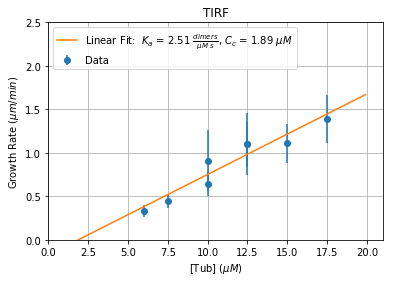

In [46]:
a1 , a0 = np.polyfit(data['tub conc'], data['growth mean'], 1)
y_int = -a0/a1
x_range = np.arange(0,20,0.1)

plt.errorbar(data['tub conc'], data['growth mean'], yerr=data['growth std'], fmt='o')
plt.plot(x_range, a1*x_range+a0)
plt.legend(('Linear Fit:  'r'$K_a$'' = %.2f 'r'$\frac{dimers}{\mu M \; s}$'', 'r'$C_c$'' = %.2f 'r'$\mu M$' %(a1*27.1, y_int),'Data'),loc='upper left')
plt.xlabel('[Tub] ' r'$(\mu M)$')
plt.ylabel('Growth Rate ' r'$(\mu m / min)$')
plt.ylim(0,2.5)
plt.xlim(0,21)
plt.grid(True)
plt.title('TIRF');
plt.savefig(path+date+'_growth.pdf')
plt.savefig(path+date+'_growth.png')

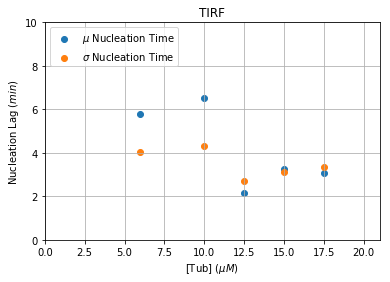

In [10]:
plt.scatter(data['tub conc'], data['nuc-lag mean'])
plt.scatter(data.index, data['nuc-lag std'])
plt.legend(( r'$\mu$' ' Nucleation Time',r'$\sigma$' ' Nucleation Time'),loc='upper left')
plt.xlabel('[Tub] ' r'$(\mu M)$')
plt.ylabel('Nucleation Lag ' r'$(min)$')
plt.ylim(0,10)
plt.xlim(0,21)
plt.grid(True)
plt.title('TIRF');
plt.savefig(path+date+'_nuc-lag.pdf')
plt.savefig(path+date+'_nuc-lag.png')

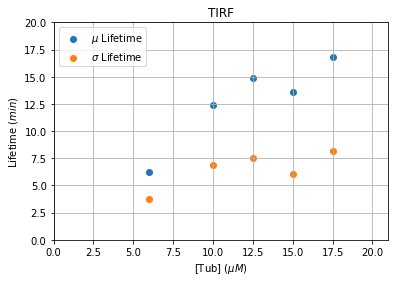

In [11]:
plt.scatter(data.index, data['lifetime mean'])
plt.scatter(data.index, data['lifetime std'])
plt.legend(( r'$\mu$' ' Lifetime',r'$\sigma$' ' Lifetime'),loc='upper left')
plt.xlabel('[Tub] ' r'$(\mu M)$')
plt.ylabel('Lifetime ' r'$(min)$')
plt.ylim(0,20)
plt.xlim(0,21)
plt.grid(True)
plt.title('TIRF');
plt.savefig(path+date+'_lifetime.pdf')
plt.savefig(path+date+'_lifetime.png')

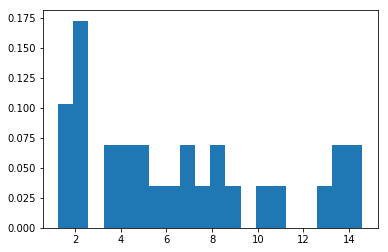

In [12]:
track = dynamics(2)

for i in [1] :
    weights = np.ones_like(track[i])/float(len(track[i]))
    plt.hist(track[i],20, weights=weights)

In [31]:
get_mean_std(name[0])

,15,6,10,17.5,12.5,12.5.1,10.1,7.5
growth mean,1.109388,0.333000,0.910345,1.390769,1.096216,1.104828,0.642857,0.448000
growth std,0.222864,0.066495,0.348778,0.274220,0.254813,0.355152,0.134017,0.081346


In [36]:
df = pd.DataFrame(conc,columns=conc, index='tubulin c')

TypeError: Index(...) must be called with a collection of some kind, 'tubulin c' was passed

In [34]:
conc

[15, 6, 10, 17.5, 12.5, 12.5, 10, 7.5]